Daily Challenge: Breast Cancer Prediction


👩‍🏫 👩🏿‍🏫 What You’ll learn
Data visualization with scatter plots.
Basic understanding of classification models
Interpreting the results.


🛠️ What you will create
In this notebook, you will be using 4 classification models- Logistic Regression, K Nearest Neighbours, Random Forests and Support Vector Machines (SVM).
dataset available here



Your Task
Exploratory Data Analysis
Use pandas to load the dataset and examine the first few rows.
Check and handle the missing values.
Drop any unnecessary column
Create a Countplot to display diagnosis from magma

Data Preprocessing, Building Models and Evaluation :
counts of unique rows in the ‘diagnosis’ column
map categorical values to numerical values
Splitting the data into train and test
Implement logistic regression and print the accuracy.
Implement K Nearest Neighbours and print the accuracy.
Implement Random Forests and print the accuracy.
Implement Support Vector Machines (SVM) and print the accuracy.
Which is the best model ?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [10]:
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543


In [6]:
df = pd.read_csv('data-selected-columns.csv')
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   569 non-null    int64  
 1   diagnosis            569 non-null    object 
 2   radius_mean          569 non-null    float64
 3   texture_mean         569 non-null    float64
 4   perimeter_mean       569 non-null    float64
 5   area_mean            569 non-null    float64
 6   smoothness_mean      569 non-null    float64
 7   compactness_mean     569 non-null    float64
 8   concavity_mean       569 non-null    float64
 9   concave points_mean  569 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 44.6+ KB


In [5]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [7]:
df.drop('id', axis=1, inplace=True)

/tmp/ipykernel_5986/4244379610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


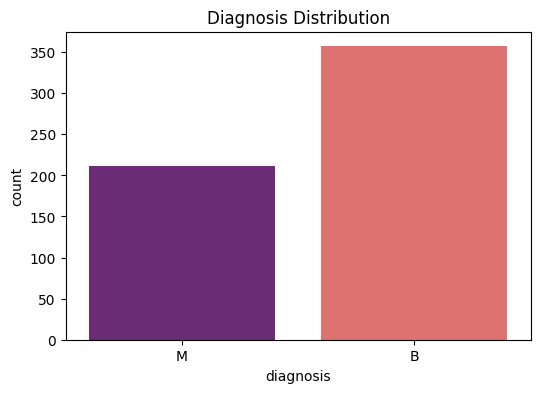

In [8]:
# Countplot
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='diagnosis',
    palette='magma'
)

plt.title('Diagnosis Distribution')
plt.show()

In [13]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


The countplot shows that the dataset contains more benign (B) cases than malignant (M) cases. There are approximately 357 benign samples and 212 malignant samples. The classes are slightly imbalanced but still suitable for classification modeling.

In [14]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

In [15]:
df['diagnosis'].head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [16]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
X.describe()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200


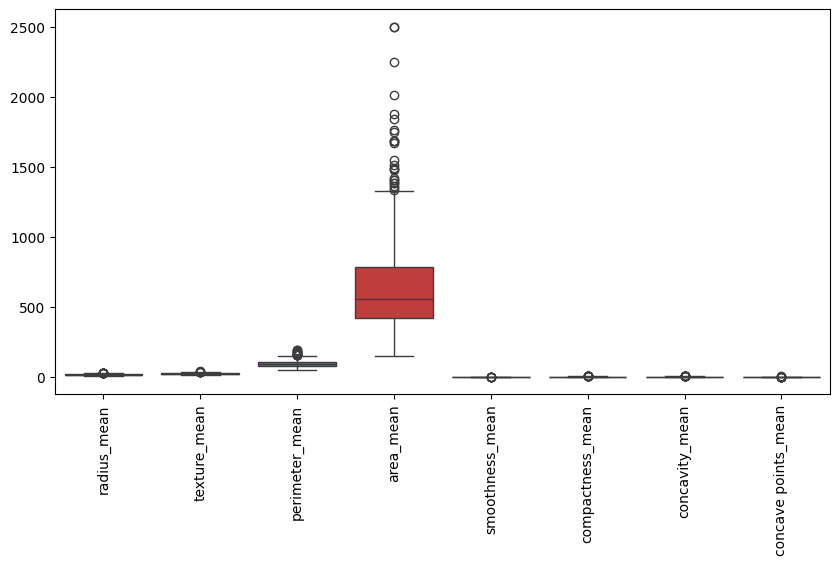

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.show()

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pd.DataFrame(X_train).describe()

,0,1,2,3,4,5,6,7
count,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02
mean,3.904081e-18,-7.808162e-18,2.342449e-17,-1.561632e-17,3.904081e-18,-1.952040e-17,5.856121e-18,3.904081e-18
std,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00
min,-1.819583e+00,-2.223500e+00,-1.809497e+00,-1.365036e+00,-3.100011e+00,-1.607228e+00,-1.119899e+00,-1.269910e+00
25%,-6.830930e-01,-7.075360e-01,-6.907613e-01,-6.602049e-01,-7.132037e-01,-7.770872e-01,-7.505387e-01,-7.349048e-01
50%,-2.314983e-01,-1.185158e-01,-2.429378e-01,-2.895973e-01,-8.082013e-02,-2.413402e-01,-3.446456e-01,-3.911235e-01
75%,4.593426e-01,5.631988e-01,4.884799e-01,3.193386e-01,6.331729e-01,5.281282e-01,5.473870e-01,6.737569e-01
max,3.961679e+00,4.715674e+00,3.976811e+00,5.208312e+00,4.864642e+00,3.964311e+00,4.256736e+00,4.022271e+00


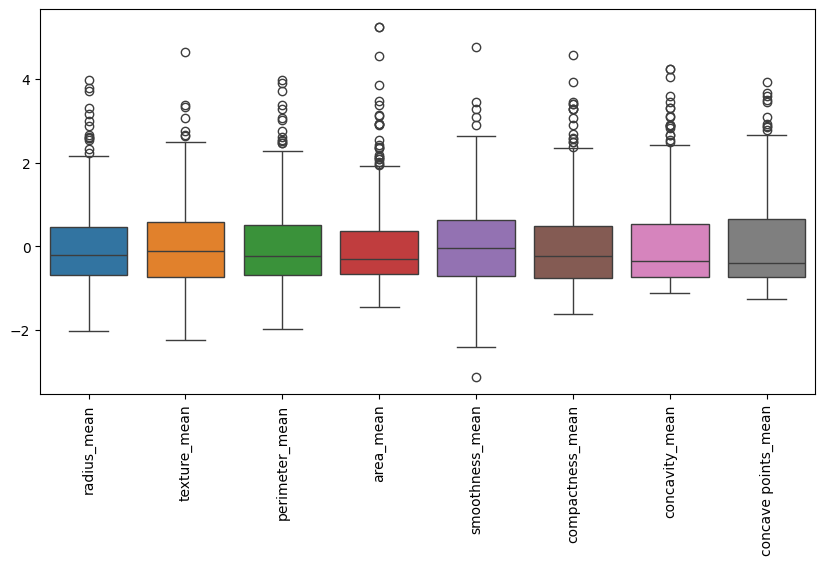

In [25]:
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

plt.figure(figsize=(10,5))
sns.boxplot(data=X_scaled)
plt.xticks(rotation=90)
plt.show()

In [26]:
# logistic regression
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9473684210526315


In [27]:
# K Nearest Neighbours
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9385964912280702


In [29]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9473684210526315


In [30]:
# Support Vector Machine (SVM)
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9824561403508771


In [32]:
# model comparison
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'SVM'
    ],
    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,SVM,0.982456
0,Logistic Regression,0.947368
2,Random Forest,0.947368
1,KNN,0.938596


In [34]:
#best model
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model            SVM
Accuracy    0.982456
Name: 3, dtype: object
